# 01: Feature Engineering, Label Creation, and Smoothing (Price Target)

Refactor objective: pivot from return prediction to **next-day closing price** prediction while preserving exponential smoothing for noise reduction.

## Chapter 1: Introduction & Problem Context

- Domain Overview: We model daily AAPL market behavior using price and technical-indicator features.
- Analytical Objective: Predict **next-day Close price** (`target_close_1d`) from today's engineered features.
- Type of ML Problem: Supervised **regression** (continuous target).

In [53]:
import importlib.metadata  # ensures importlib.metadata is available in some Python envs
import numpy as np
import pandas as pd
import pandas_ta as ta
import yfinance as yf
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 200)


In [54]:
TICKER = "AAPL"
PERIOD = "5y"
INTERVAL = "1d"
ALPHA = 0.2

OUT_DIR = Path("../data/processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Shared dataset path consumed by Notebook 02 and Notebook 03
FEATURE_PATH_PARQUET = OUT_DIR / "aapl_features_smoothed.parquet"
FEATURE_PATH_CSV = OUT_DIR / "aapl_features_smoothed.csv"

# Single source-of-truth modeling config for downstream notebooks
MODEL_CONFIG_PATH = OUT_DIR / "modeling_config.json"


## Chapter 2: Dataset & Preprocessing

- Dataset Description: Daily OHLCV from Yahoo Finance via `yfinance`.
- Data Cleaning: Column normalization, date indexing, missing-value handling.
- Feature Engineering: 8 engineered features (mostly unbounded).
- Data Transformation: Exponential smoothing on adjusted close/high/low/volume.
- Train/Test Strategy: Time-aware split will be applied in Notebook 03.

In [55]:
df = yf.download(
    TICKER,
    period=PERIOD,
    interval=INTERVAL,
    auto_adjust=False,
    actions=False,
    progress=False,
)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)


In [56]:
def exp_smooth(series: pd.Series, alpha: float = 0.2) -> pd.Series:
    return series.ewm(alpha=alpha, adjust=False).mean()

s_adj_close = exp_smooth(df["Adj Close"], ALPHA)
s_high = exp_smooth(df["High"], ALPHA)
s_low = exp_smooth(df["Low"], ALPHA)
s_volume = exp_smooth(df["Volume"], ALPHA)

In [ ]:
feat = pd.DataFrame(index=df.index)

# Keep core price references
feat["close"] = df["Close"]
feat["Adj Close"] = df["Adj Close"]
feat["adj_close_smooth"] = s_adj_close
feat["target_ret_1d_pct"] = (df["Adj Close"].pct_change().shift(-1) * 100)


# Indicator engineering
feat["rsi_14"] = ta.rsi(s_adj_close, length=14)
macd_df = ta.macd(s_adj_close, fast=12, slow=26, signal=9)
feat["macd_hist_12_26_9"] = macd_df["MACDh_12_26_9"]

adx_df = ta.adx(high=s_high, low=s_low, close=s_adj_close, length=14)
feat["adx_14"] = adx_df["ADX_14"]
feat["atr_14"] = ta.atr(high=s_high, low=s_low, close=s_adj_close, length=14)
feat["obv"] = ta.obv(close=s_adj_close, volume=s_volume)
feat["sma_10"] = ta.sma(s_adj_close, length=10)
feat["ema_20"] = ta.ema(s_adj_close, length=20)

bb_df = ta.bbands(s_adj_close, length=20, std=2)
bb_col = next((col for col in bb_df.columns if col.startswith("BBB_20_2")), None)
feat["bb_bandwidth_20_2"] = bb_df[bb_col]

# Candidate features available for modeling (centralized here)
all_feature_cols = [
    "rsi_14",
    "macd_hist_12_26_9",
    "bb_bandwidth_20_2",
    "adx_14",
    "obv",
    "adj_close_smooth",
    "ema_20",
    "atr_14",
]

# Targets available for training
feat["target_close_1d"] = df["Adj Close"].shift(-1)

# Training target (edit ONLY this variable to change prediction objective)
target_col = "target_close_1d"


In [ ]:
rows_before = len(feat)
feat = feat.dropna().copy()
rows_after = len(feat)

summary = pd.DataFrame({
    "metric": ["rows_before_dropna", "rows_after_dropna", "rows_removed"],
    "value": [rows_before, rows_after, rows_before - rows_after],
})

print("Final modeling shape:", feat.shape)
display(summary)

missing_tbl = pd.DataFrame({
    "missing_count": feat.isna().sum(),
}).sort_values("missing_count", ascending=False)
missing_tbl

Final modeling shape: (1222, 11)


,metric,value
0,rows_before_dropna,1256
1,rows_after_dropna,1222
2,rows_removed,34


,missing_count
close,0
Adj Close,0
rsi_14,0
macd_hist_12_26_9,0
bb_bandwidth_20_2,0
adx_14,0
obv,0
adj_close_smooth,0
ema_20,0
atr_14,0


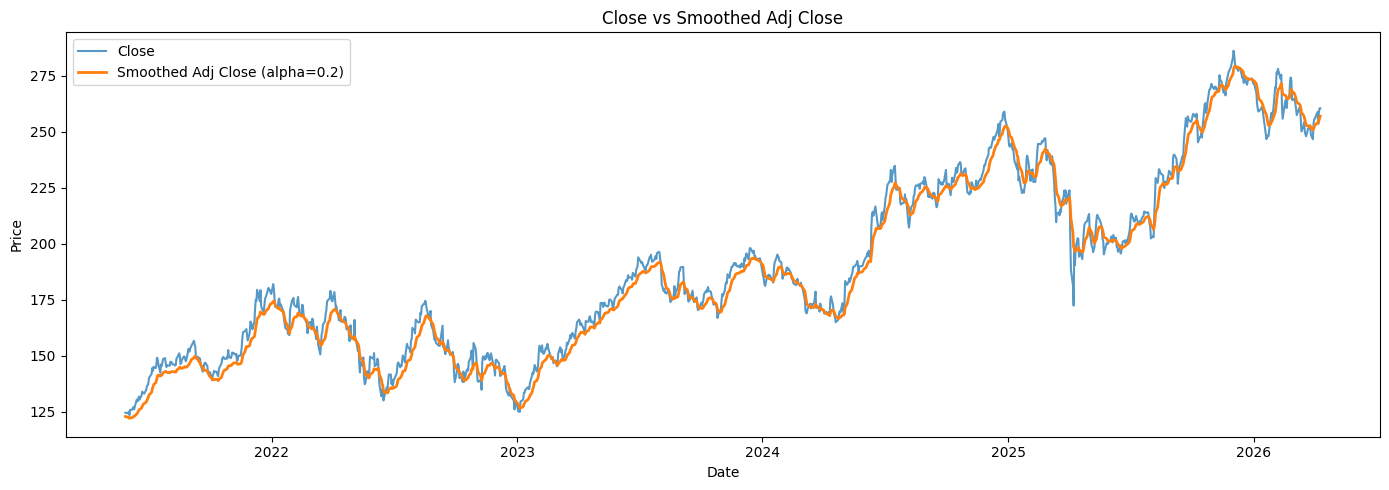

In [59]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(feat.index, feat["close"], label="Close", alpha=0.75)
ax.plot(feat.index, feat["adj_close_smooth"], label=f"Smoothed Adj Close (alpha={ALPHA})", linewidth=2)
ax.set_title("Close vs Smoothed Adj Close")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
import json

saved_to = []

feat.to_csv(FEATURE_PATH_CSV, index=True)
saved_to.append(str(FEATURE_PATH_CSV))

model_config = {
    "data_csv": str(FEATURE_PATH_CSV),
    "all_feature_cols": all_feature_cols,
    "train_feature_cols": all_feature_cols,
    "target_options": "target_close_1d",
    "target_col": target_col,
}

MODEL_CONFIG_PATH.write_text(json.dumps(model_config, indent=2), encoding="utf-8")

print("Saved processed feature dataset to:")
for path in saved_to:
    print("-", path)

print("Saved modeling config to:")
print("-", MODEL_CONFIG_PATH)

feat.head()


Saved processed feature dataset to:
- ..\data\processed\aapl_features_smoothed.csv
Saved modeling config to:
- ..\data\processed\modeling_config.json


,close,Adj Close,rsi_14,macd_hist_12_26_9,bb_bandwidth_20_2,adx_14,obv,adj_close_smooth,ema_20,atr_14,target_close_1d
Date,,,,,,,,,,,
2021-05-28,124.610001,121.575752,10.999672,0.292014,6.769326,60.467386,-1.091632e+09,122.914882,125.065328,4.259406,121.253777
2021-06-01,124.279999,121.253777,10.208605,0.273615,6.054047,61.439864,-1.166708e+09,122.582661,124.828883,4.241362,122.014771
2021-06-02,125.059998,122.014771,9.945273,0.262070,5.490137,62.446581,-1.238624e+09,122.469083,124.604140,4.224313,120.531807
2021-06-03,123.540001,120.531807,9.084392,0.237352,5.070052,63.543032,-1.311403e+09,122.081628,124.363901,4.191804,122.824577
2021-06-04,125.889999,122.824577,12.222462,0.239340,4.522976,64.620172,-1.238146e+09,122.230218,124.160693,4.188175,122.834343
